# Introducing wavefront aberrations

Optical aberrations in Fiatlux can be represented as OPD masks.

Here we introduce a differential piston between the left and right halves
of the pupil and observe its effect on the PSF.

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import Band, Spectrum
from fiatlux.core.source import PlaneWave
from fiatlux.optics.elements.mask import CircularAperture, Step
from fiatlux.optics.propagator import MFTPropagator
from fiatlux.system.optical_system import SerialSystem

## Build the reference system

In [2]:
D = 1.0
wavelength = 1.65e-6
focal_length = 10.0

N_pupil = 256
N_focal = 256

pupil_grid = Grid(
    nx=N_pupil,
    ny=N_pupil,
    dx=D / N_pupil,
    dy=D / N_pupil,
)

focal_grid = Grid(
    nx=N_focal,
    ny=N_focal,
    dx=focal_length * wavelength / D / 4,
    dy=focal_length * wavelength / D / 4,
)

band = Band(
    central_wavelength=wavelength,
    delta_wavelength=0.0,
    f0=368.0,
)

spectrum = Spectrum(magnitude=0, band=band, samples=1)
source = PlaneWave(spectrum=spectrum)

aperture = CircularAperture(grid=pupil_grid, radius=D / 2)
propagator = MFTPropagator(
    focal_length=focal_length,
    output_grid=focal_grid,
)

reference_system = SerialSystem(elements=[aperture, propagator])

reference_result = reference_system.run(source)

## Add a differential piston

The OPD difference is \(\lambda/4\), corresponding to a phase difference

\[
\Delta\phi = 2\pi \frac{\lambda/4}{\lambda} = \frac{\pi}{2}.
\]

In [6]:
step = Step(
    grid=pupil_grid,
    piston=wavelength / 4,
)

aberrated_system = SerialSystem(
    elements=[
        aperture,
        step,
        propagator,
    ]
)

aberrated_result = aberrated_system.run(source)

## Inspect the pupil phase

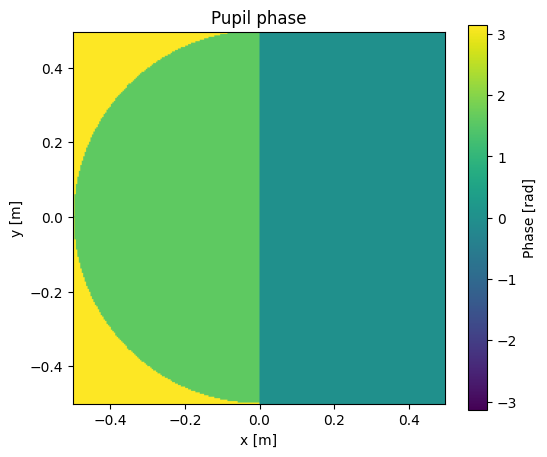

In [4]:
field_after_step = aberrated_result.field_at(step)

plt.figure(figsize=(6, 5))
plt.imshow(
    field_after_step.phase()[0].cpu(),
    origin="lower",
    extent=[
        float(pupil_grid.x.min()),
        float(pupil_grid.x.max()),
        float(pupil_grid.y.min()),
        float(pupil_grid.y.max()),
    ],
    vmin=-torch.pi,
    vmax=torch.pi,
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Pupil phase")
plt.colorbar(label="Phase [rad]")
plt.show()

## Compare the perfect and aberrated PSFs

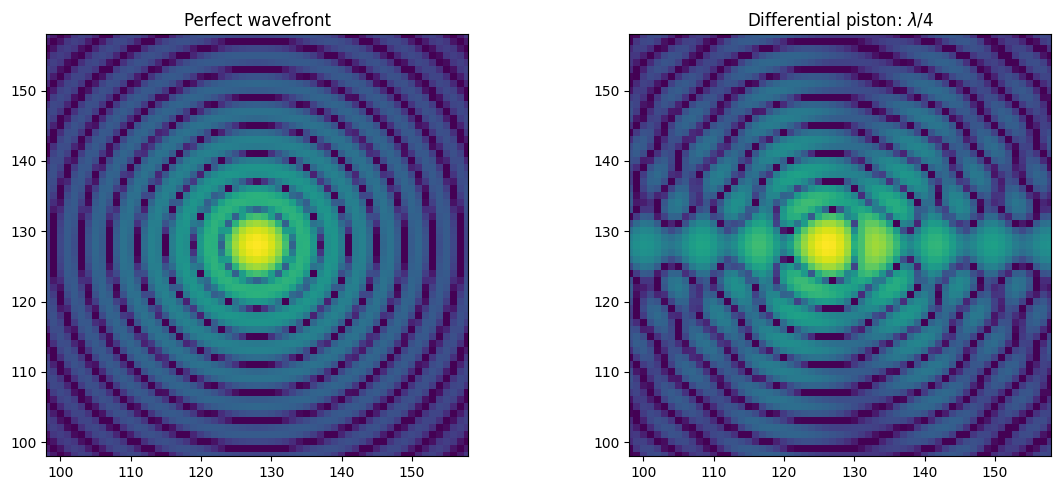

In [5]:
psf_reference = reference_result.field_at(propagator).intensity().sum(0)
psf_aberrated = aberrated_result.field_at(propagator).intensity().sum(0)

psf_reference = psf_reference / psf_reference.max()
psf_aberrated = psf_aberrated / psf_aberrated.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(
    psf_reference.cpu(),
    origin="lower",
    norm=LogNorm(vmin=1e-5, vmax=1),
)
axes[0].set_title("Perfect wavefront")

axes[1].imshow(
    psf_aberrated.cpu(),
    origin="lower",
    norm=LogNorm(vmin=1e-5, vmax=1),
)
axes[1].set_title(r"Differential piston: $\lambda/4$")

for ax in axes:
    ax.set_xlim(N_focal // 2 - 30, N_focal // 2 + 30)
    ax.set_ylim(N_focal // 2 - 30, N_focal // 2 + 30)

plt.tight_layout()
plt.show()